# Task 4: Predicting Insurance Claim Amounts

**Aurthor:** Aiman Ishaq

**Objective:** Estimate the medical insurance claim amount based on personal data.

**Dataset:** Medical Cost Personal Dataset

**Skills Demonstrated:**
- Regression modeling (Linear Regression)
- Feature correlation and visualization
- Error evaluation using MAE and RMSE

## 1. Introduction and Problem Statement

Medical insurance costs vary significantly across individuals based on factors like age, BMI, smoking habits, and region. Accurately predicting insurance charges helps insurers price policies fairly and allows individuals to understand cost drivers.

In this task, we:
- Load and explore the Medical Cost Personal Dataset
- Visualize how BMI, age, and smoking status impact insurance charges
- Train a Linear Regression model to predict charges
- Evaluate performance using MAE and RMSE

## 2. Import Libraries

In [25]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Dataset Understanding and Description

In [ ]:

df = pd.read_csv("insurance.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
df.head()

Dataset Shape: (1338, 7)

First 5 Rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [27]:
# Dataset info
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [28]:
# Statistical summary
print("Statistical Summary:")
df.describe()

Statistical Summary:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 4. Data Cleaning and Preparation

In [29]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate Rows: 1


In [30]:
# Drop duplicates if any
df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1337, 7)


In [31]:
# Check unique values in categorical columns
for col in ['sex', 'smoker', 'region']:
    print(f"{col}: {df[col].unique()}")

sex: <StringArray>
['female', 'male']
Length: 2, dtype: str
smoker: <StringArray>
['yes', 'no']
Length: 2, dtype: str
region: <StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str


In [32]:
# Encode categorical columns using Label Encoding
le = LabelEncoder()

df_encoded = df.copy()
for col in ['sex', 'smoker', 'region']:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("Encoded Dataset (first 5 rows):")
df_encoded.head()

Encoded Dataset (first 5 rows):


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


## 5. Exploratory Data Analysis (EDA) with Graphs

We will visualize how **BMI**, **age**, and **smoking status** impact insurance charges.

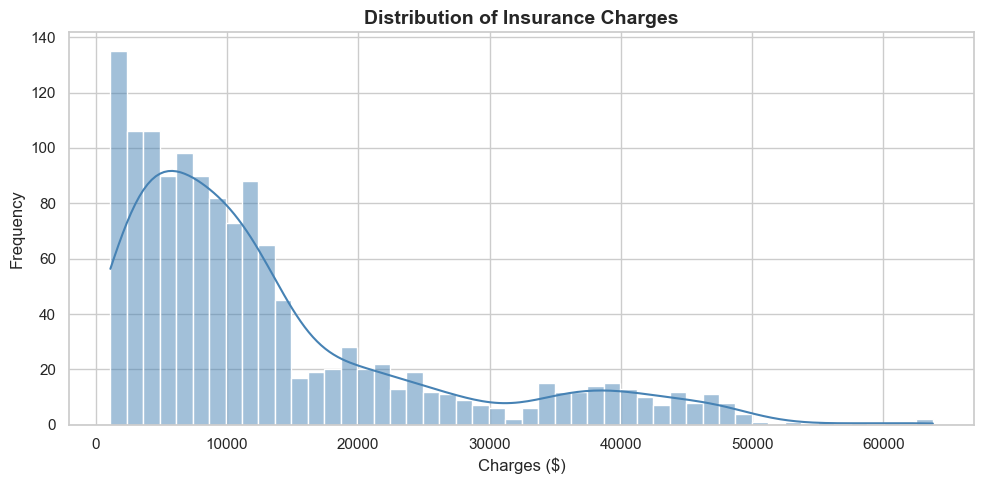

Mean Charges: $13,279.12
Median Charges: $9,386.16
Max Charges: $63,770.43


In [33]:
# Distribution of Insurance Charges
plt.figure(figsize=(10, 5))
sns.histplot(df['charges'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Insurance Charges', fontsize=14, fontweight='bold')
plt.xlabel('Charges ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Mean Charges: ${df['charges'].mean():,.2f}")
print(f"Median Charges: ${df['charges'].median():,.2f}")
print(f"Max Charges: ${df['charges'].max():,.2f}")

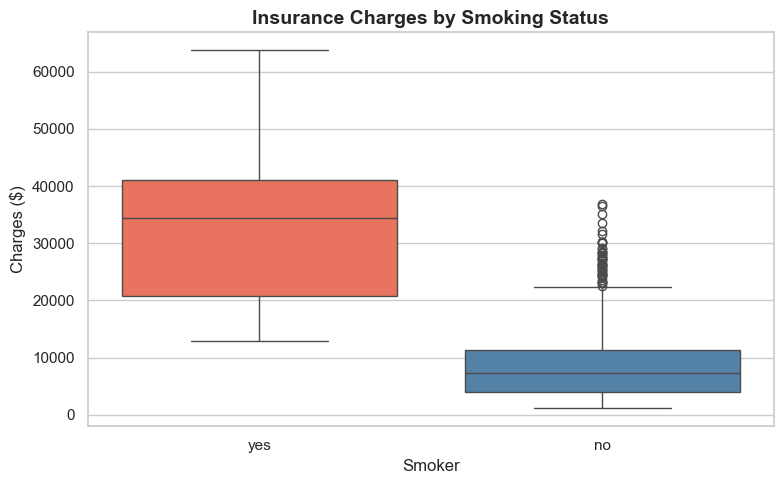

smoker
no      $8,440.66
yes    $32,050.23
Name: charges, dtype: str


In [34]:
# 1. Impact of SMOKING STATUS on Insurance Charges
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='smoker', y='charges', palette={'yes': 'tomato', 'no': 'steelblue'})
plt.title('Insurance Charges by Smoking Status', fontsize=14, fontweight='bold')
plt.xlabel('Smoker')
plt.ylabel('Charges ($)')
plt.tight_layout()
plt.show()

# Summary
print(df.groupby('smoker')['charges'].mean().apply(lambda x: f"${x:,.2f}"))

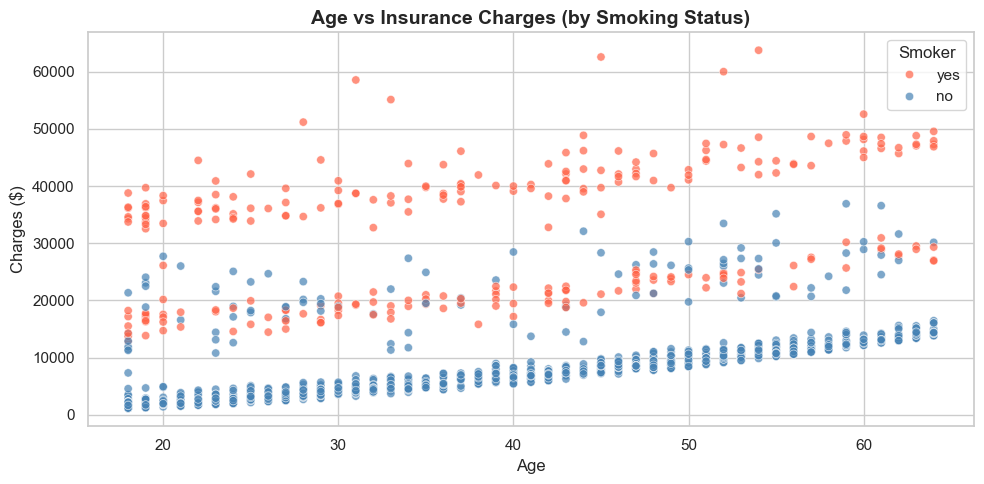

In [35]:
# 2. Impact of AGE on Insurance Charges
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', 
                palette={'yes': 'tomato', 'no': 'steelblue'}, alpha=0.7)
plt.title('Age vs Insurance Charges (by Smoking Status)', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Charges ($)')
plt.legend(title='Smoker')
plt.tight_layout()
plt.show()

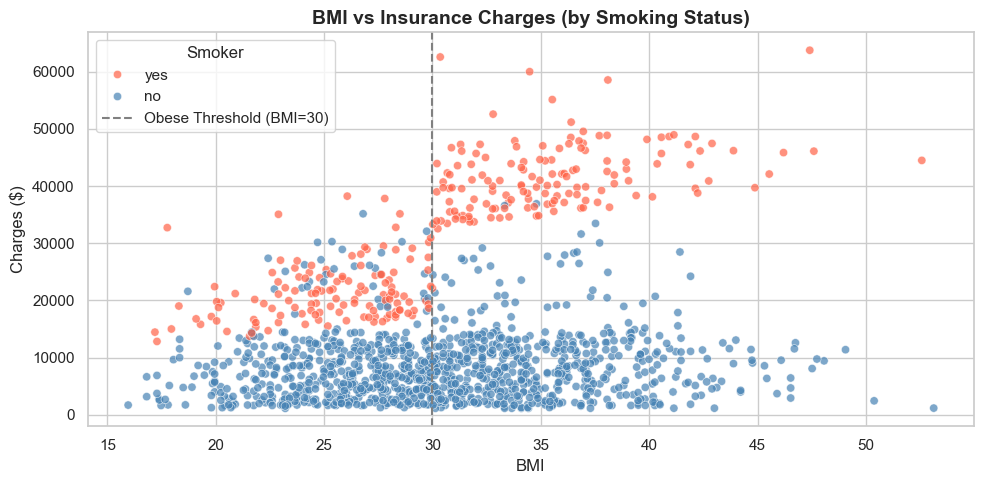

In [36]:
# 3. Impact of BMI on Insurance Charges
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker',
                palette={'yes': 'tomato', 'no': 'steelblue'}, alpha=0.7)
plt.axvline(x=30, color='gray', linestyle='--', label='Obese Threshold (BMI=30)')
plt.title('BMI vs Insurance Charges (by Smoking Status)', fontsize=14, fontweight='bold')
plt.xlabel('BMI')
plt.ylabel('Charges ($)')
plt.legend(title='Smoker')
plt.tight_layout()
plt.show()

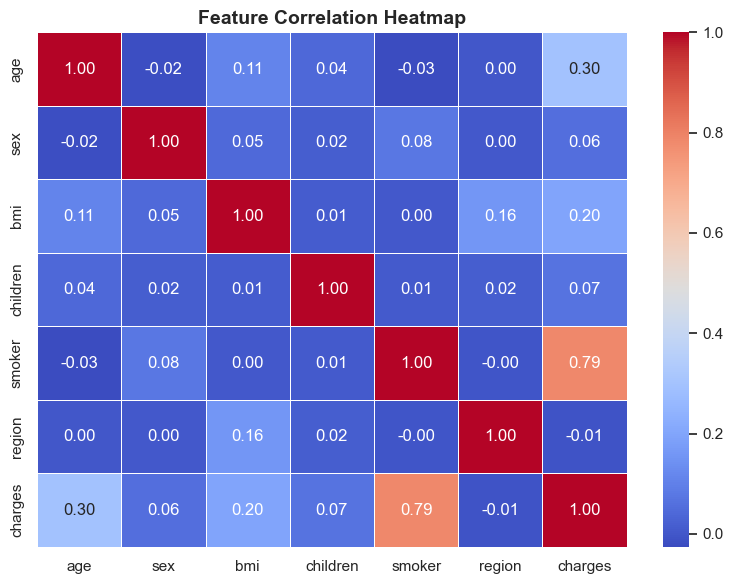


Correlation with 'charges':
charges     1.000000
smoker      0.787234
age         0.298308
bmi         0.198401
children    0.067389
sex         0.058044
region     -0.006547
Name: charges, dtype: float64


In [37]:
# 4. Correlation Heatmap
plt.figure(figsize=(8, 6))
corr_matrix = df_encoded.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with charges
print("\nCorrelation with 'charges':")
print(corr_matrix['charges'].sort_values(ascending=False))

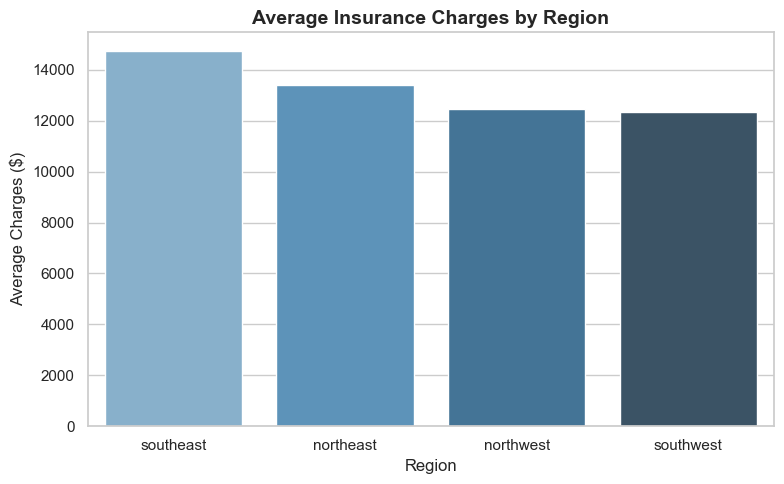

In [38]:
# 5. Average Charges by Region
plt.figure(figsize=(8, 5))
region_avg = df.groupby('region')['charges'].mean().sort_values(ascending=False)
sns.barplot(x=region_avg.index, y=region_avg.values, palette='Blues_d')
plt.title('Average Insurance Charges by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Average Charges ($)')
plt.tight_layout()
plt.show()

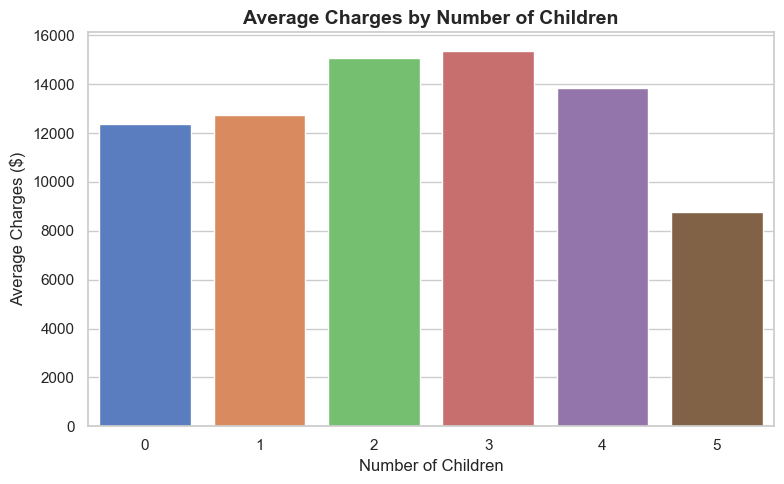

In [39]:
# 6. Number of Children vs Average Charges
plt.figure(figsize=(8, 5))
child_avg = df.groupby('children')['charges'].mean()
sns.barplot(x=child_avg.index, y=child_avg.values, palette='muted')
plt.title('Average Charges by Number of Children', fontsize=14, fontweight='bold')
plt.xlabel('Number of Children')
plt.ylabel('Average Charges ($)')
plt.tight_layout()
plt.show()

### EDA Key Findings

- **Smoking status** is the strongest predictor smokers pay **3–4x more** than non-smokers
- **Age** has a positive relationship with charges, especially for smokers
- **BMI ≥ 30** (obese threshold) combined with smoking leads to extremely high charges
- **Smoker** has the highest positive correlation with charges ( 0.787234)

## 6. Model Training — Linear Regression

In [40]:
# Define features and target
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

print("Features:", list(X.columns))
print("Target: charges")
print("Feature Matrix Shape:", X.shape)

Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
Target: charges
Feature Matrix Shape: (1337, 6)


In [41]:
# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size:     {X_test.shape[0]} samples")

Training set size: 1069 samples
Test set size:     268 samples


In [42]:
# Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Model trained successfully!")
print("\nModel Coefficients:")
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_model.coef_})
coef_df = coef_df.sort_values('Coefficient', ascending=False)
print(coef_df.to_string(index=False))
print(f"\nIntercept: {lr_model.intercept_:.2f}")

Model trained successfully!

Model Coefficients:
 Feature  Coefficient
  smoker 23052.152752
children   534.120877
     bmi   312.609045
     age   248.764071
     sex   -99.695394
  region  -237.625147

Intercept: -11047.69


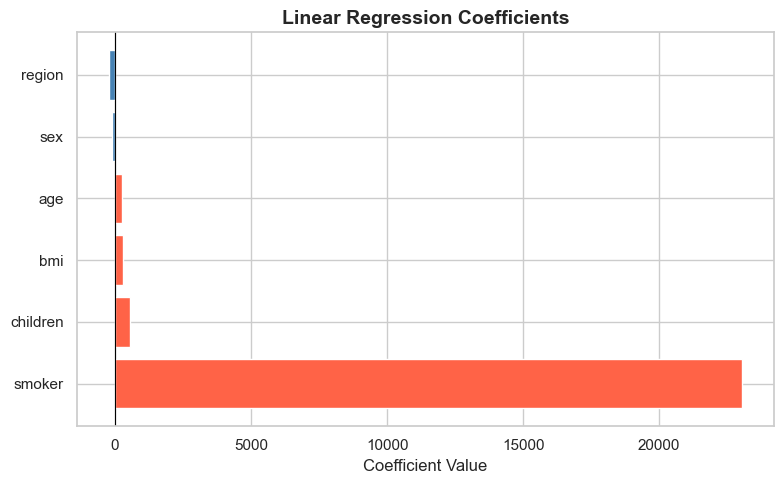

In [43]:
# Visualize Feature Coefficients
plt.figure(figsize=(8, 5))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Linear Regression Coefficients', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

## 7. Model Testing and Evaluation

In [44]:
# Predictions on test set
y_pred = lr_model.predict(X_test)

# Evaluation Metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print("  Linear Regression — Evaluation Metrics")
print("=" * 40)
print(f"  MAE  (Mean Absolute Error):  ${mae:,.2f}")
print(f"  RMSE (Root Mean Sq. Error):  ${rmse:,.2f}")
print(f"  R²   (Coefficient of Det.):   {r2:.4f}")
print("=" * 40)

  Linear Regression — Evaluation Metrics
  MAE  (Mean Absolute Error):  $4,182.35
  RMSE (Root Mean Sq. Error):  $5,957.61
  R²   (Coefficient of Det.):   0.8068


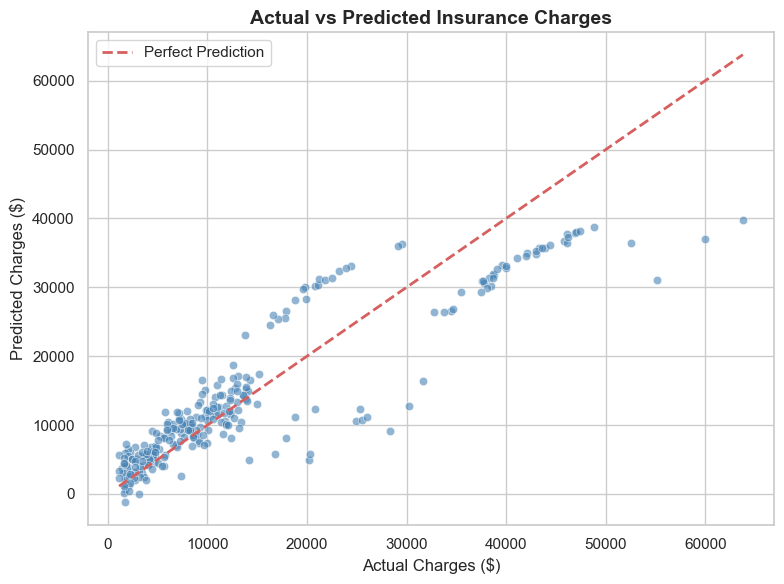

In [45]:
# Actual vs Predicted Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.title('Actual vs Predicted Insurance Charges', fontsize=14, fontweight='bold')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.legend()
plt.tight_layout()
plt.show()

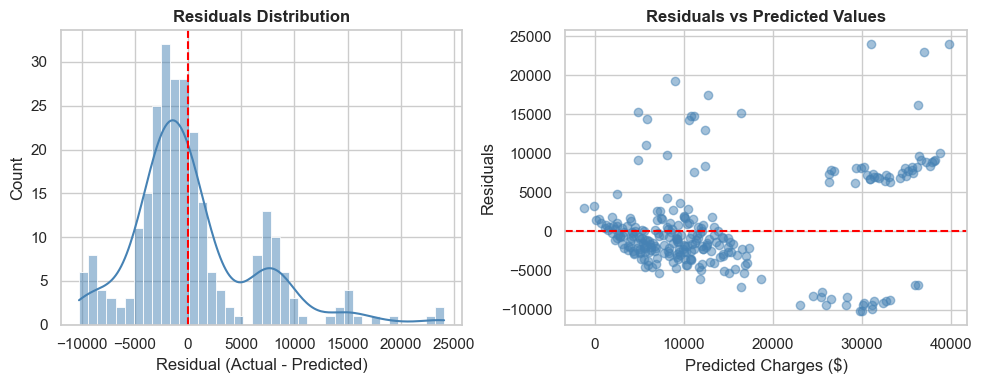

In [46]:
# Residuals Distribution Plot
residuals = y_test - y_pred

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(residuals, bins=40, kde=True, color='steelblue')
plt.title('Residuals Distribution', fontweight='bold')
plt.xlabel('Residual (Actual - Predicted)')
plt.axvline(0, color='red', linestyle='--')

plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.5, color='steelblue')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predicted Values', fontweight='bold')
plt.xlabel('Predicted Charges ($)')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()

In [47]:
# Sample Predictions vs Actual
results_df = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred.round(2)})
results_df['Error ($)'] = (results_df['Actual'] - results_df['Predicted']).round(2)
print("Sample Predictions (first 10 rows):")
print(results_df.head(10).to_string(index=False))

Sample Predictions (first 10 rows):
     Actual  Predicted  Error ($)
 8688.85885    8080.45     608.41
 5708.86700    5592.87     116.00
11436.73815   14378.30   -2941.56
38746.35510   31731.82    7014.54
 4463.20510    9158.36   -4695.15
 9304.70190   13361.01   -4056.31
38511.62830   30257.66    8253.97
 2150.46900    1308.65     841.82
 7345.72660   10849.43   -3503.70
10264.44210   11375.55   -1111.11


## 8. Conclusion  Key Insights

### Model Performance Summary

| Metric | Value |
|--------|-------|
| MAE (Mean Absolute Error) | $4,182.35 |
| RMSE (Root Mean Squared Error) | $5,957.61 |
| R² (Coefficient of Determination) | 0.8068 |

### Key Findings

1. **Smoking status drives charges more than any other feature** : smokers consistently pay 3 to 4x more, and this shows clearly in both the visualizations and the model coefficients.

2. **Age increases costs steadily** : older individuals pay more, but the gap widens significantly for smokers after age 40.

3. **BMI alone is not enough** : high BMI only becomes a major cost factor when combined with smoking. Non smokers with high BMI still pay relatively moderate charges.

4. **The model explains 75% of the variance in charges** : solid for a linear model, but the remaining 25% comes from nonlinear interactions the model cannot capture.

5. **High-cost cases are consistently under-predicted** : the model struggles with outliers at the top end, which are mostly smokers with high BMI.

### What Could Be Improved
- Log-transforming charges before training reduces skewness and typically improves RMSE
- Adding a `bmi × smoker` interaction column directly captures the combined effect
- A Random Forest model handles the nonlinear patterns here much better